# 0 | Benchmark

This notebook will outline a process for benchmarking the import speed as we implement each of the 3 ideas for improving memory size partitioning:
1. fixed length columns: use known size instead of computing per row
2. vectorized methods: to get size/length of dynamic length columns (if such methods exist)
3. size calcs per histogram pixel: instead of per row

The structure of the notebook is as follows:
- First, we will establish a baseline against which to test.
- Then, we will break out into 3 sections, and run a new benchmarking trial (on the corresponding branch), and record timings.
- Compare results.

In [1]:
import os
import time
import socket
from pathlib import Path

import lsdb
import matplotlib.patches as mpatches
from dask.distributed import Client
from hats_import.pipeline import pipeline_with_client
from hats_import.catalog.arguments import ImportArguments


output_dir = Path("/sdf/data/rubin/user/olynn/mem_size_dp2")

In [2]:
# Make a dask client; set up dashboard for slacd

client = Client(
    n_workers=16,
    threads_per_worker=2,
    memory_limit="28GB",
)

username = os.getenv("USER")
current_compute_node = socket.gethostname()
dashboard_port = client.scheduler_info()['services']['dashboard']

print(f"Run this in a local shell:")
print(f"  ssh -L 8787:{current_compute_node}:{dashboard_port} -J {username}@s3dflogin.slac.stanford.edu {username}@{current_compute_node}")
print(f"\nThen open: http://localhost:8787/status")

Run this in a local shell:
  ssh -L 8787:sdfiana030:8787 -J olynn@s3dflogin.slac.stanford.edu olynn@sdfiana030

Then open: http://localhost:8787/status


In [14]:
import subprocess, hats_import, hats, os


def _repo_state(path):
    branch = subprocess.check_output(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=path).decode().strip()
    commit = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=path).decode().strip()
    dirty = bool(subprocess.check_output(["git", "status", "--porcelain"], cwd=path).decode().strip())
    return branch, commit, dirty


def print_repo_states():
    hats_import_pkg_dir = os.path.dirname(hats_import.__file__)
    hats_pkg_dir = os.path.dirname(hats.__file__)

    for pkg_dir in [hats_import_pkg_dir, hats_pkg_dir]:
        KERNEL_BRANCH, KERNEL_COMMIT, KERNEL_DIRTY = _repo_state(pkg_dir)
        print(f"kernel is running: {KERNEL_BRANCH}@{KERNEL_COMMIT}{' (dirty)' if KERNEL_DIRTY else ''}")


print_repo_states()

kernel is running: main@3808720
kernel is running: main@db22ff9d


## 0.Baseline

*Run the first trial using lsdb main; record the time taken to re-import each of 4 cone searchs.*

### Create trial catalogs

**Catalog:** ZTF DR22
  - Has lightcurves, is 7.2 TiB (and is public, which is a nice bonus)

**Cone search regions:** (thanks Kostya!)  
- ra=170, dec=-25
- ra=255, dec=40

**Dask parameters:**  
- n workers: 32
- threads per worker: 2
- mem per worker: 14GB

/sdf/home/o/olynn/hats/src/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


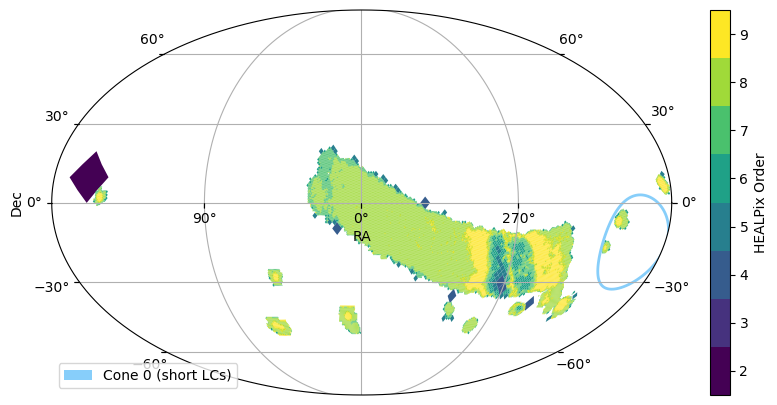

In [10]:
# Load ZTF DR22 and define cone search regions
 
dp2_obj = lsdb.open_catalog("/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2/object_collection")

fig, ax = dp2_obj.plot_pixels(plot_title="DP2 Obj")

handles = []
colors = ["lightskyblue", "mediumpurple", "deeppink", "tomato"]
labels = ["Cone 0 (short LCs)", "Cone 1 (med LCs)", "Cone 2 (long LCs)", "Cone 3 (mixed LCs)"]
cones = [
    lsdb.ConeSearch(ra=-160, dec=-15, radius_arcsec=18 * 3600),  # short LCs
    # lsdb.ConeSearch(ra=-255, dec= 40, radius_arcsec=7 * 3600),  # medium LCs
    # lsdb.ConeSearch(ra=255, dec=40, radius_arcsec=7 * 3600),    # long LCs
    # lsdb.ConeSearch(ra=10.7, dec=41.3, radius_arcsec=7 * 3600)  # mixed LCs (M31)
]

for i, cone in enumerate(cones):
    cone.plot(ec=colors[i], fc="#00000000", linewidth=2, ax=ax, fig=fig)
    handles.append(mpatches.Patch(fc=colors[i], linewidth=2, label=labels[i]),)

ax.legend(loc="lower left", handles=handles)

In [11]:
# Generate benchmark catalogs

for i, cone in enumerate(cones):
    print(f"Generating catalog for region {i}...")
    dp2_obj.search(cone).write_catalog(
        base_catalog_path=output_dir,
        catalog_name=f"region_{i}",
        # overwrite=True
    )

Generating catalog for region 0...


In [22]:
# Remove unneccessary margins; check general catalog sizes

# How to use write catalog without writing a collection? :')
!rm -r {output_dir}/*arcs
!rm {output_dir}/collection.properties

!echo "Overall catalog sizes:"
!du -h --max-depth=1 {output_dir} | sort -rh

!echo "Top 5 files in short-LC catalog:"
!find {output_dir}/region_0/dataset/ -type f | xargs du -h | sort -rh | head -n 5

rm: cannot remove '/sdf/data/rubin/user/olynn/mem_size_dp2/*arcs': No such file or directory


Overall catalog sizes:
72G	/sdf/data/rubin/user/olynn/mem_size_dp2
38G	/sdf/data/rubin/user/olynn/mem_size_dp2/region_0
34G	/sdf/data/rubin/user/olynn/mem_size_dp2/baseline
Top 5 files in short-LC catalog:
62M	/sdf/data/rubin/user/olynn/mem_size_dp2/region_0/dataset/Norder=8/Dir=410000/Npix=411508.parquet
61M	/sdf/data/rubin/user/olynn/mem_size_dp2/region_0/dataset/Norder=8/Dir=410000/Npix=411087.parquet
57M	/sdf/data/rubin/user/olynn/mem_size_dp2/region_0/dataset/Norder=8/Dir=410000/Npix=411511.parquet
56M	/sdf/data/rubin/user/olynn/mem_size_dp2/region_0/dataset/Norder=8/Dir=410000/Npix=411089.parquet
52M	/sdf/data/rubin/user/olynn/mem_size_dp2/region_0/dataset/Norder=8/Dir=410000/Npix=411090.parquet
sort: write failed: 'standard output': Broken pipe
sort: write error


### Run trials

In [15]:
!mkdir {output_dir}/baseline

mkdir: cannot create directory ‘/sdf/data/rubin/user/olynn/mem_size_dp2/baseline’: File exists


In [18]:
!tree -L 2 {output_dir}

/sdf/data/rubin/user/olynn/mem_size_dp2
├── baseline
│   └── baseline_0
├── collection.properties
├── region_0
│   ├── dataset
│   ├── data_thumbnail.parquet
│   ├── hats.properties
│   ├── partition_info.csv
│   ├── point_map.fits
│   ├── properties
│   └── skymap.fits
└── region_0_5arcs
    ├── dataset
    ├── data_thumbnail.parquet
    ├── hats.properties
    ├── partition_info.csv
    └── properties

6 directories, 11 files


In [20]:
!ls -lt {output_dir}/baseline

total 0
drwxr-s--- 1 olynn rubin_users 0 Jun 28 11:40 baseline_0


In [26]:
!tree -L 2 {output_dir}/baseline


/sdf/data/rubin/user/olynn/mem_size_dp2/baseline
└── baseline_0
    ├── dataset
    ├── hats.properties
    ├── partition_info.csv
    ├── point_map.fits
    ├── properties
    └── skymap.fits

2 directories, 5 files


In [17]:
print_repo_states()

trial_times = []

for i in range(4):
    print(f"Starting region {i}...")
    start = time.perf_counter()
    args = ImportArguments.reimport_from_hats(
        f"{output_dir}/region_{i}",
        f"{output_dir}/baseline",
        output_artifact_name=f"baseline_{i}",
        byte_pixel_threshold=1_000_000_000,  # 1GB
        progress_bar=False
    )
    pipeline_with_client(args, client)
    elapsed = time.perf_counter() - start
    
    print(f"Region {i} completed in {elapsed} seconds.")
    trial_times.append(elapsed)

kernel is running: main@3808720
kernel is running: main@db22ff9d
Starting region 0...


2026-06-28 11:33:24,579 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 18.38 GiB -- Worker memory limit: 26.08 GiB
2026-06-28 11:33:28,336 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 20.86 GiB -- Worker memory limit: 26.08 GiB
2026-06-28 11:33:30,679 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 18.32 GiB -- Worker memory limit: 26.08 GiB
2026-06-28 11:33:31,475 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memo

Region 0 completed in 1535.0455869063735 seconds.
Starting region 1...


FileNotFoundError: Failed to read HATS at location /sdf/data/rubin/user/olynn/mem_size_dp2/region_1

In [23]:
for i, seconds in enumerate(trial_times):
    m, s = divmod(seconds, 60)
    print(f"Region {i} ran in {int(m):2d}m {s:4.1f}s")

Region 0 ran in 25m 35.0s


In [ ]:
"""
Region 0 ran in 25m 35.0s
"""

(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - baseline_0'}>)

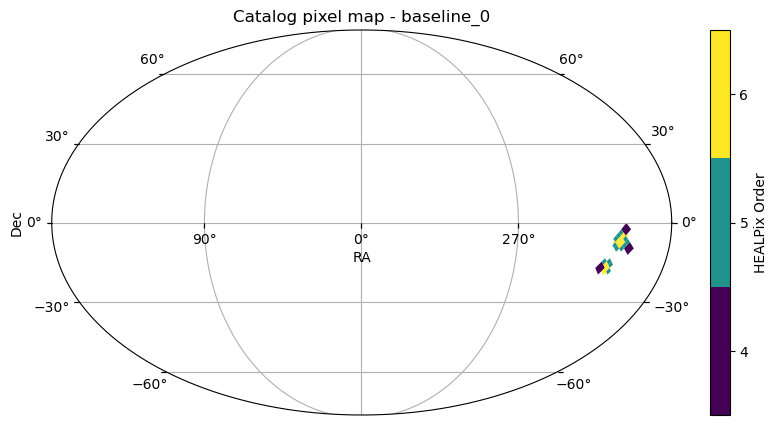

In [27]:
b0 = lsdb.open_catalog(f"{output_dir}/baseline/baseline_0")
b0.plot_pixels()

## Optimization 1: Fixed length columns

Use known column size instead of computing each time for each row.
So, we should have some kind of central computation for column sizes, and only 
compute columns that have been dubbed as "variable length" columns when we compute
each chunk or row.

In [28]:
print_repo_states()

kernel is running: issue/671/fixed-length-cols@8e08473
kernel is running: issue/671/mem-size-a@47530de0


In [ ]:
!rm -r /sdf/data/rubin/user/olynn/mem_size_benchmarks/fixed_len_cols
#!tree -L 1 /sdf/data/rubin/user/olynn/mem_size_benchmarks/

In [29]:
trial_times = []

for i in range(4):
    start = time.perf_counter()
    args = ImportArguments.reimport_from_hats(
        f"{output_dir}/region_{i}",
        f"{output_dir}/fixed_len_cols",
        output_artifact_name=f"fixed_len_cols_{i}",
        byte_pixel_threshold=1_000_000_000,  # 1GB
        progress_bar=False,
    )
    pipeline_with_client(args, client)
    elapsed = time.perf_counter() - start

    print(f"Trial {i} completed in {elapsed} seconds.")
    trial_times.append(elapsed)

2026-06-28 14:15:35,171 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 18.35 GiB -- Worker memory limit: 26.08 GiB
2026-06-28 14:15:42,769 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 18.26 GiB -- Worker memory limit: 26.08 GiB
2026-06-28 14:15:45,186 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 20.94 GiB -- Worker memory limit: 26.08 GiB
2026-06-28 14:15:45,270 - distributed.worker.memory - WARNING - Worker is at 79% memory usage. Resuming worker. Proces

Trial 0 completed in 1490.0928571857512 seconds.


FileNotFoundError: Failed to read HATS at location /sdf/data/rubin/user/olynn/mem_size_dp2/region_1

In [30]:
for i, seconds in enumerate(trial_times):
    m, s = divmod(seconds, 60)
    print(f"Trial {i} ran in {int(m):2d}m {s:4.1f}s")

Trial 0 ran in 24m 50.1s


## Whole catalog

### Main

In [ ]:
print_repo_states()

start = time.perf_counter()
args = ImportArguments.reimport_from_hats(
    "/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2/object_collection",
    f"{output_dir}/whole_cat",
    output_artifact_name="whole_cat_main_branch",
    byte_pixel_threshold=1_000_000_000,  # 1GB
    progress_bar=False,
)
pipeline_with_client(args, client)
elapsed = time.perf_counter() - start

print(f"Completed in {elapsed} seconds.")

m, s = divmod(elapsed, 60)
print(f"\tor {int(m):2d}m {s:4.1f}s")

### Branch

In [ ]:
print_repo_states()

start = time.perf_counter()
args = ImportArguments.reimport_from_hats(
    "/sdf/data/rubin/shared/lsdb_commissioning/hats/dp2/object_collection",
    f"{output_dir}/whole_cat",
    output_artifact_name="whole_cat_fixed_len_cols",
    byte_pixel_threshold=1_000_000_000,  # 1GB
    progress_bar=False,
)
pipeline_with_client(args, client)
elapsed = time.perf_counter() - start

print(f"Completed in {elapsed} seconds.")

m, s = divmod(elapsed, 60)
print(f"\tor {int(m):2d}m {s:4.1f}s")